In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [2]:
(X_train, y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()

In [3]:
print("Images in X_train: ", len(X_train))
print("Images in y_train: ", len(y_train))
print("Images in X_test: ", len(X_test))
print("Images in y_test: ", len(y_test))


Images in X_train:  60000
Images in y_train:  60000
Images in X_test:  10000
Images in y_test:  10000


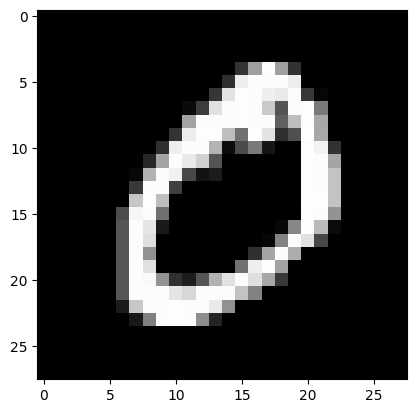

In [4]:
plt.imshow(X_train[1], cmap="gray")
plt.show()

In [5]:
X_train_flattened = X_train.reshape(len(X_train), 28*28 ) / 255
X_train_flattened.shape

(60000, 784)

In [6]:
X_test_flattened = X_test.reshape(len(X_test), 28*28 ) / 255
X_test_flattened.shape

(10000, 784)

In [8]:
model = keras.Sequential([
    keras.layers.Dense(
        128,
        input_shape=(784,),
        activation = 'relu'),

    keras.layers.Dense(
        64,
        activation="relu"
    ),

    keras.layers.Dense(
        10,
        activation='softmax'
    )
])

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
    )

model.fit(X_train_flattened, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9283 - loss: 0.2397
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9686 - loss: 0.1048
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9772 - loss: 0.0728
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9825 - loss: 0.0543
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9852 - loss: 0.0455


In [ ]:
y_pred = model.predict(X_test_flattened)
np.argmax(y_pred[2])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


np.int64(1)

In [ ]:
from sklearn.metrics import accuracy_score
print("Accuracy: ", accuracy_score(y_test, np.argmax(y_pred, axis=1)))

Accuracy:  0.9257
